# Homework3 RNN 实现古诗生成
**学号**：SA25006010
**姓名**：周子涵


## 一、任务说明与方法概览
数据集由四个 json 文件组成，即 poet.song，40k 到 43k。
要求：以“明月”为总起词，通过训练使模型能够生成固定格式的古诗。在这里，使 RNN 生成七言绝句。

数据预处理：要求生成固定格式的古诗，如五言绝句、七言绝句等，基于这个要求，一般而言需要确保使用的训练数据中都是该格式的古诗；

神经网络构建：在 Python 中使用 Pytorch 等神经网络框架构建课上讲到的LSTM 等 RNN 类型网络，也可以使用更复杂的网络，可以选择使用多个隐藏层和不同的激活函数测试效果；

模型测试与评估：要求绘制一张 loss 图展示构建的神经网络可收敛。

## 二、代码实现

In [13]:
# 导入依赖库
import json
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [14]:
# ===================== 1. 超参数设置 =====================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
EPOCHS = 200
LR = 0.001
MAX_LEN = 28  # 七言绝句4句×7字=28字
START_WORD = "明月"  # 作业要求总起词

In [15]:
# ===================== 2. 数据预处理 =====================
def load_data(file_path):
    """加载古诗json数据，筛选七言绝句"""
    poems = []
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    for item in data:
        paragraphs = item['paragraphs']
        # 筛选：2句、每句14字、无特殊符号
        if len(paragraphs) == 2:
            valid = True
            poem = ""
            for sent in paragraphs:
                sent = sent.strip()
                if len(sent) != 16:
                    valid = False
                    break
                sent = sent[:7] + sent[8:15]
                poem += sent
            poems.append(poem)
    return poems

def build_vocab(poems):
    """构建汉字-索引映射词典"""
    vocab = set()
    for poem in poems:
        vocab.update(poem)
    vocab = sorted(list(vocab))
    char2idx = {char: i+1 for i, char in enumerate(vocab)}  # 0留给填充
    char2idx['<PAD>'] = 0
    idx2char = {i: char for char, i in char2idx.items()}
    return char2idx, idx2char, len(char2idx)

def poem2tensor(poems, char2idx, max_len):
    """古诗转张量"""
    data = []
    for poem in poems:
        idx = [char2idx[c] for c in poem]
        # 填充/截断到固定长度
        if len(idx) < max_len:
            idx += [char2idx['<PAD>']] * (max_len - len(idx))
        else:
            idx = idx[:max_len]
        data.append(idx)
    data = np.array(data, dtype=np.int64)
    assert data.ndim == 2 and data.shape[1] == max_len, f"data shape error: {data.shape}"
    # 输入x=前n-1字，目标y=后n-1字
    x = torch.tensor(data[:, :-1], dtype=torch.long).to(DEVICE)
    y = torch.tensor(data[:, 1:], dtype=torch.long).to(DEVICE)
    return x, y

# 加载数据集

poem0 = load_data("poet.song.40000.json")
poem1 = load_data("poet.song.41000.json")
poem2 = load_data("poet.song.42000.json")
poem3 = load_data("poet.song.43000.json")
poems = poem0 + poem1 + poem2 + poem3
print(f"加载到诗歌数量: {len(poems)}")
assert len(poems) > 0, "没有加载到任何诗歌，请检查数据文件或筛选条件！"
char2idx, idx2char, VOCAB_SIZE = build_vocab(poems)
x_data, y_data = poem2tensor(poems, char2idx, MAX_LEN)

加载到诗歌数量: 1213


========== 开始训练 ==========
Epoch [1/200], Average Loss: 6.2360
Epoch [2/200], Average Loss: 5.3396
Epoch [3/200], Average Loss: 5.2402
Epoch [4/200], Average Loss: 5.2194
Epoch [5/200], Average Loss: 5.2045
Epoch [6/200], Average Loss: 5.1941
Epoch [7/200], Average Loss: 5.1825
Epoch [8/200], Average Loss: 5.1672
Epoch [9/200], Average Loss: 5.1458
Epoch [10/200], Average Loss: 5.1189
Epoch [11/200], Average Loss: 5.0982
Epoch [12/200], Average Loss: 5.0679
Epoch [13/200], Average Loss: 5.0278
Epoch [14/200], Average Loss: 4.9889
Epoch [15/200], Average Loss: 4.9366
Epoch [16/200], Average Loss: 4.8830
Epoch [17/200], Average Loss: 4.8176
Epoch [18/200], Average Loss: 4.7273
Epoch [19/200], Average Loss: 4.6347
Epoch [20/200], Average Loss: 4.5383
Epoch [21/200], Average Loss: 4.4416
Epoch [22/200], Average Loss: 4.3429
Epoch [23/200], Average Loss: 4.2319
Epoch [24/200], Average Loss: 4.1204
Epoch [25/200], Average Loss: 4.0270
Epoch [26/200], Average Loss: 3.9101
Epoch [27/200], Aver

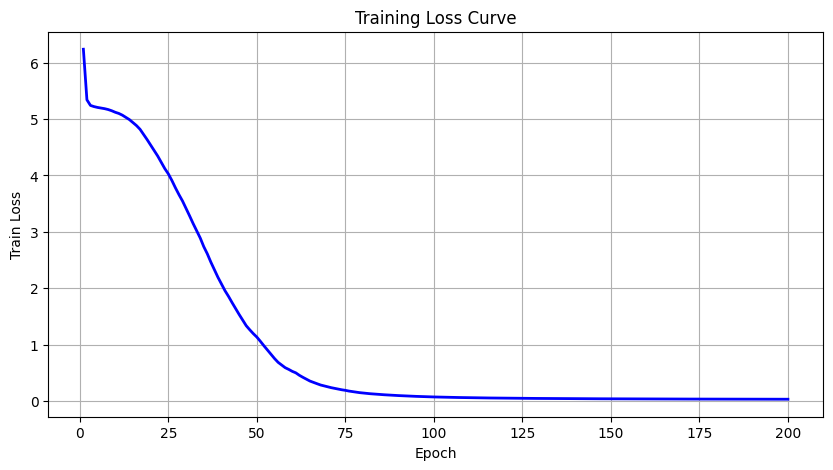

In [16]:
# ===================== 3. LSTM模型定义 =====================
class PoemLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers):
        super(PoemLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        out, hidden = self.lstm(embed, hidden)
        out = self.fc(out)
        return out, hidden

# 初始化模型
model = PoemLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ===================== 4. 模型训练 =====================
loss_history = []
print("========== 开始训练 ==========")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    # 分批训练
    for i in range(0, len(x_data), BATCH_SIZE):
        x_batch = x_data[i:i+BATCH_SIZE]
        y_batch = y_data[i:i+BATCH_SIZE]
        
        optimizer.zero_grad()
        output, _ = model(x_batch)
        # 调整维度计算损失
        loss = criterion(output.reshape(-1, VOCAB_SIZE), y_batch.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / (len(x_data) // BATCH_SIZE + 1)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Average Loss: {avg_loss:.4f}")

# ===================== 5. 绘制Loss曲线 =====================
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), loss_history, 'b-', linewidth=2)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.grid(True)
plt.savefig('loss_curve.png')  # 保存图片
plt.show()

In [17]:
# ===================== 6. 古诗生成（明月开头·七言绝句） =====================
def generate_poem(start_word, model, char2idx, idx2char, max_len=28):
    model.eval()
    poem = list(start_word)
    hidden = None
    with torch.no_grad():
        for _ in range(max_len - len(start_word)):
            x = torch.tensor([[char2idx[c] for c in poem]], dtype=torch.long).to(DEVICE)
            output, hidden = model(x, hidden)
            # 取最后一个字的预测概率
            prob = output.argmax(-1)[:, -1].item()
            poem.append(idx2char[prob])
    # 按7字一句拆分
    poem = ''.join(poem)
    return [poem[i*7:(i+1)*7] for i in range(4)]

# 生成古诗
print("\n========== 生成古诗 ==========")
result = generate_poem(START_WORD, model, char2idx, idx2char)
for idx, sent in enumerate(result, 1):
    print(f"{sent}")


========== 生成古诗 ==========
明月圓如何事更
滿庭春歸回雪頭
雲盡未未知思留
鳴今夜堂有靜只
